<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/Airbnb_Berlin_Price_Pedict_EDA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
# !pip install missingno
# !pip install geopy
# !pip install matplotlib

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# from pandas_profiling import ProfileReport
import numpy as np
import missingno as msno
sns.set()
plt.style.use('ggplot')
import warnings
import datetime as dt

from sklearn import ensemble, tree, linear_model
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from scipy.stats import norm
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [84]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
df_EDA2 = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA2.pkl')

In [86]:
df = df_EDA2.copy()

In [87]:
# df = df.drop(columns=['Listing ID','Host ID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Listing ID                     23460 non-null  int64  
 1   Accomodates                    23460 non-null  float64
 2   Accuracy Rating                18862 non-null  float64
 3   Bathrooms                      23431 non-null  float64
 4   Bedrooms                       23440 non-null  float64
 5   Beds                           23426 non-null  float64
 6   Checkin Rating                 18844 non-null  float64
 7   Cleanliness Rating             18866 non-null  float64
 8   Communication Rating           18860 non-null  float64
 9   Guests Included                23460 non-null  float64
 10  Host Response Rate             12984 non-null  float64
 11  Latitude                       23460 non-null  float64
 12  Location Rating                18845 non-null  floa

# Data Cleansing

## Defines data columns Lists

In [88]:
numerical_columns = ['Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included','Min Nights','Reviews','Price']
rating_columns = ['Value Rating','Location Rating', 'Cleanliness Rating','Checkin Rating','Accuracy Rating','Communication Rating','Host Response Rate','Overall Rating']
boolean_columns = ['Is Superhost','Is Exact Location', 'Instant Bookable']
categorical_columns = ['Room Type','Property Type Reduced','Neighborhood Group','Postal Code Reduced','Host Response Time'] # , 'Neighbourhood Grouped'
categorical_encoded_columns = ['Room Type Encoded','Property Type Reduced Encoded','Neighborhood Group Encoded','Postal Code Reduced Encoded','Host Response Time Encoded']
date_columns = ['review_date','Host Since']
geo_columns = ['Latitude','Longitude']
non_categorical_columns = numerical_columns + rating_columns + boolean_columns

In [89]:
df = df[numerical_columns + rating_columns + boolean_columns + categorical_columns + date_columns + geo_columns + categorical_encoded_columns]

In [90]:
difference = list(set(df_EDA2.columns.to_list()) - set(df.columns.to_list()))
difference

['Postal Code',
 'neighbourhood',
 'Neighbourhood Grouped',
 'Listing ID',
 'Property Type']

## Checking correlations among numerical features

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Accomodates                    23460 non-null  float64
 1   Bathrooms                      23431 non-null  float64
 2   Bedrooms                       23440 non-null  float64
 3   Beds                           23426 non-null  float64
 4   Guests Included                23460 non-null  float64
 5   Min Nights                     23460 non-null  float64
 6   Reviews                        23460 non-null  float64
 7   Price                          23460 non-null  float64
 8   Value Rating                   18842 non-null  float64
 9   Location Rating                18845 non-null  float64
 10  Cleanliness Rating             18866 non-null  float64
 11  Checkin Rating                 18844 non-null  float64
 12  Accuracy Rating                18862 non-null  floa

In [92]:
correlation_matrix = numerical_df.corr(method = 'spearman')
correlation_matrix

,Accomodates,Bathrooms,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Price,Value Rating,Location Rating,Cleanliness Rating,Checkin Rating,Accuracy Rating,Communication Rating,Host Response Rate,Overall Rating,Latitude,Longitude,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
Accomodates,1.000000,0.156795,0.506295,0.718838,0.448686,0.008038,0.144479,0.536043,-0.143921,-0.051158,-0.025764,-0.040509,-0.068347,-0.046071,0.049720,-0.089425,0.040085,-0.018343,-0.459367,0.097283,0.010388,-0.045555,-0.091123
Bathrooms,0.156795,1.000000,0.246021,0.181533,0.090540,0.034927,0.003685,0.134860,0.006448,0.019550,0.006486,0.011782,0.006310,0.012124,0.025502,0.025882,0.002502,-0.038940,-0.007959,0.108463,-0.005159,-0.020376,-0.029129
Bedrooms,0.506295,0.246021,1.000000,0.526431,0.267628,0.071826,0.041620,0.342409,-0.035033,-0.020243,0.024164,0.000829,-0.015107,0.000601,0.035641,0.002468,0.004600,-0.010791,-0.227725,0.028483,0.028240,0.003581,-0.036816
Beds,0.718838,0.181533,0.526431,1.000000,0.372478,0.041228,0.092888,0.414697,-0.137571,-0.071736,-0.029026,-0.045640,-0.094385,-0.062302,0.039136,-0.096480,0.028584,-0.036266,-0.352985,0.134705,0.023762,-0.017760,-0.087497
Guests Included,0.448686,0.090540,0.267628,0.372478,1.000000,0.025692,0.207210,0.380128,-0.102300,-0.034317,0.019746,-0.008495,-0.019735,-0.008040,0.063555,-0.065424,0.028408,0.003868,-0.321135,0.060535,-0.002998,-0.058054,-0.091449
Min Nights,0.008038,0.034927,0.071826,0.041228,0.025692,1.000000,-0.106457,0.047131,0.044067,0.031919,0.012808,0.017417,0.051160,0.032425,0.003731,0.083997,-0.006008,-0.012872,-0.225168,-0.056205,0.012189,-0.014927,-0.017134
Reviews,0.144479,0.003685,0.041620,0.092888,0.207210,-0.106457,1.000000,0.093281,-0.095535,-0.012515,0.030925,0.006039,0.020380,0.005321,0.126683,-0.272095,0.039117,-0.031048,-0.035477,0.045271,0.001899,-0.074886,-0.334524
Price,0.536043,0.134860,0.342409,0.414697,0.380128,0.047131,0.093281,1.000000,-0.120510,0.107509,0.109701,0.013840,0.013267,0.024043,0.057301,0.019370,0.057407,-0.051213,-0.594762,0.122142,-0.042871,-0.201251,-0.156663
Value Rating,-0.143921,0.006448,-0.035033,-0.137571,-0.102300,0.044067,-0.095535,-0.120510,1.000000,0.316271,0.414862,0.346310,0.466973,0.370536,0.047651,0.561760,-0.028445,0.027583,0.116354,-0.027308,0.029456,0.031223,0.038229
Location Rating,-0.051158,0.019550,-0.020243,-0.071736,-0.034317,0.031919,-0.012515,0.107509,0.316271,1.000000,0.217219,0.233876,0.277268,0.254591,0.011694,0.312819,0.002605,-0.009025,-0.008191,-0.050379,-0.080322,-0.232805,-0.067337


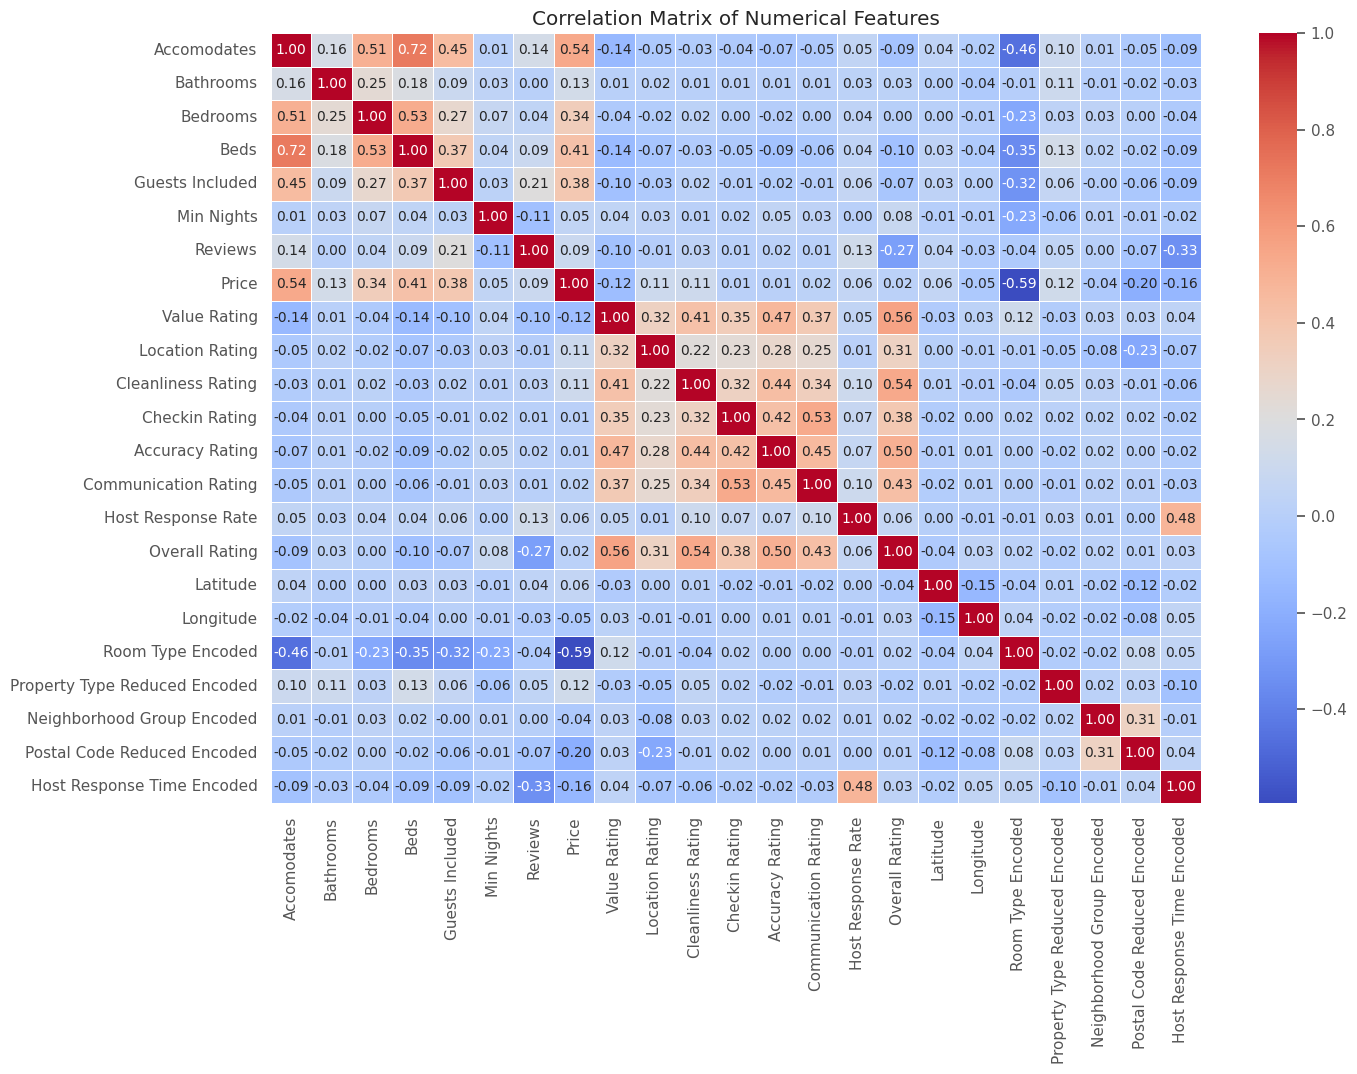

In [93]:
plt.figure(figsize=(15, 10))
numerical_df = df.select_dtypes(include=['int', 'float'])
# correlation_matrix = numerical_df.corr(method = 'spearman')
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
# plt.xticks(rotation=45)
plt.show()

In [94]:
numerical_columns

['Accomodates',
 'Bathrooms',
 'Bedrooms',
 'Beds',
 'Guests Included',
 'Min Nights',
 'Reviews',
 'Price']

## Outliers

The box extends from the first quartile (Q1) to the third quartile (Q3) of the data, with a line at the median. The whiskers extend from the box to the farthest data point lying within 1.5x the inter-quartile range (IQR) from the box. Flier points are those past the end of the whiskers. See

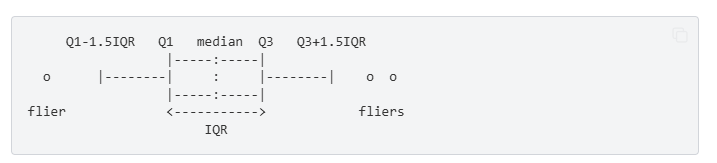

Target Value

In [95]:
outliers_columns = numerical_columns.copy()
outliers_columns.remove('Reviews')

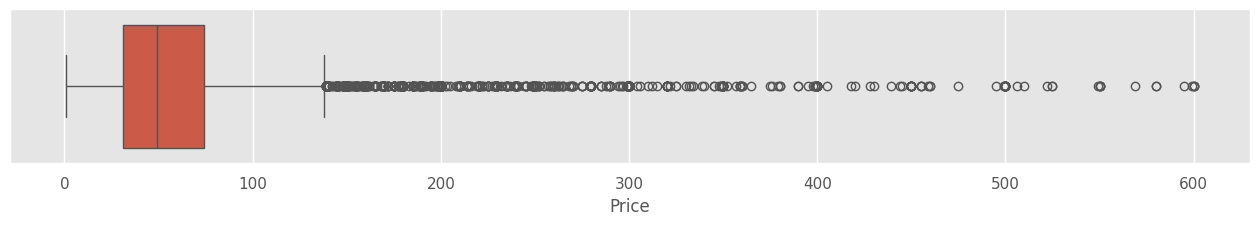

In [96]:
plt.figure(figsize=(16, 2))
sns.boxplot(df['Price'], orient='h')
plt.show()

In [97]:
df[numerical_columns].describe().loc[['min', '25%', '50%', '75%', 'max']].T

,min,25%,50%,75%,max
Accomodates,1.0,2.0,2.0,3.0,16.0
Bathrooms,0.0,1.0,1.0,1.0,8.5
Bedrooms,0.0,1.0,1.0,1.0,10.0
Beds,0.0,1.0,1.0,2.0,22.0
Guests Included,1.0,1.0,1.0,1.0,16.0
Min Nights,1.0,2.0,3.0,4.0,1000.0
Reviews,0.0,1.0,5.0,17.0,545.0
Price,1.0,31.0,49.0,74.0,600.0


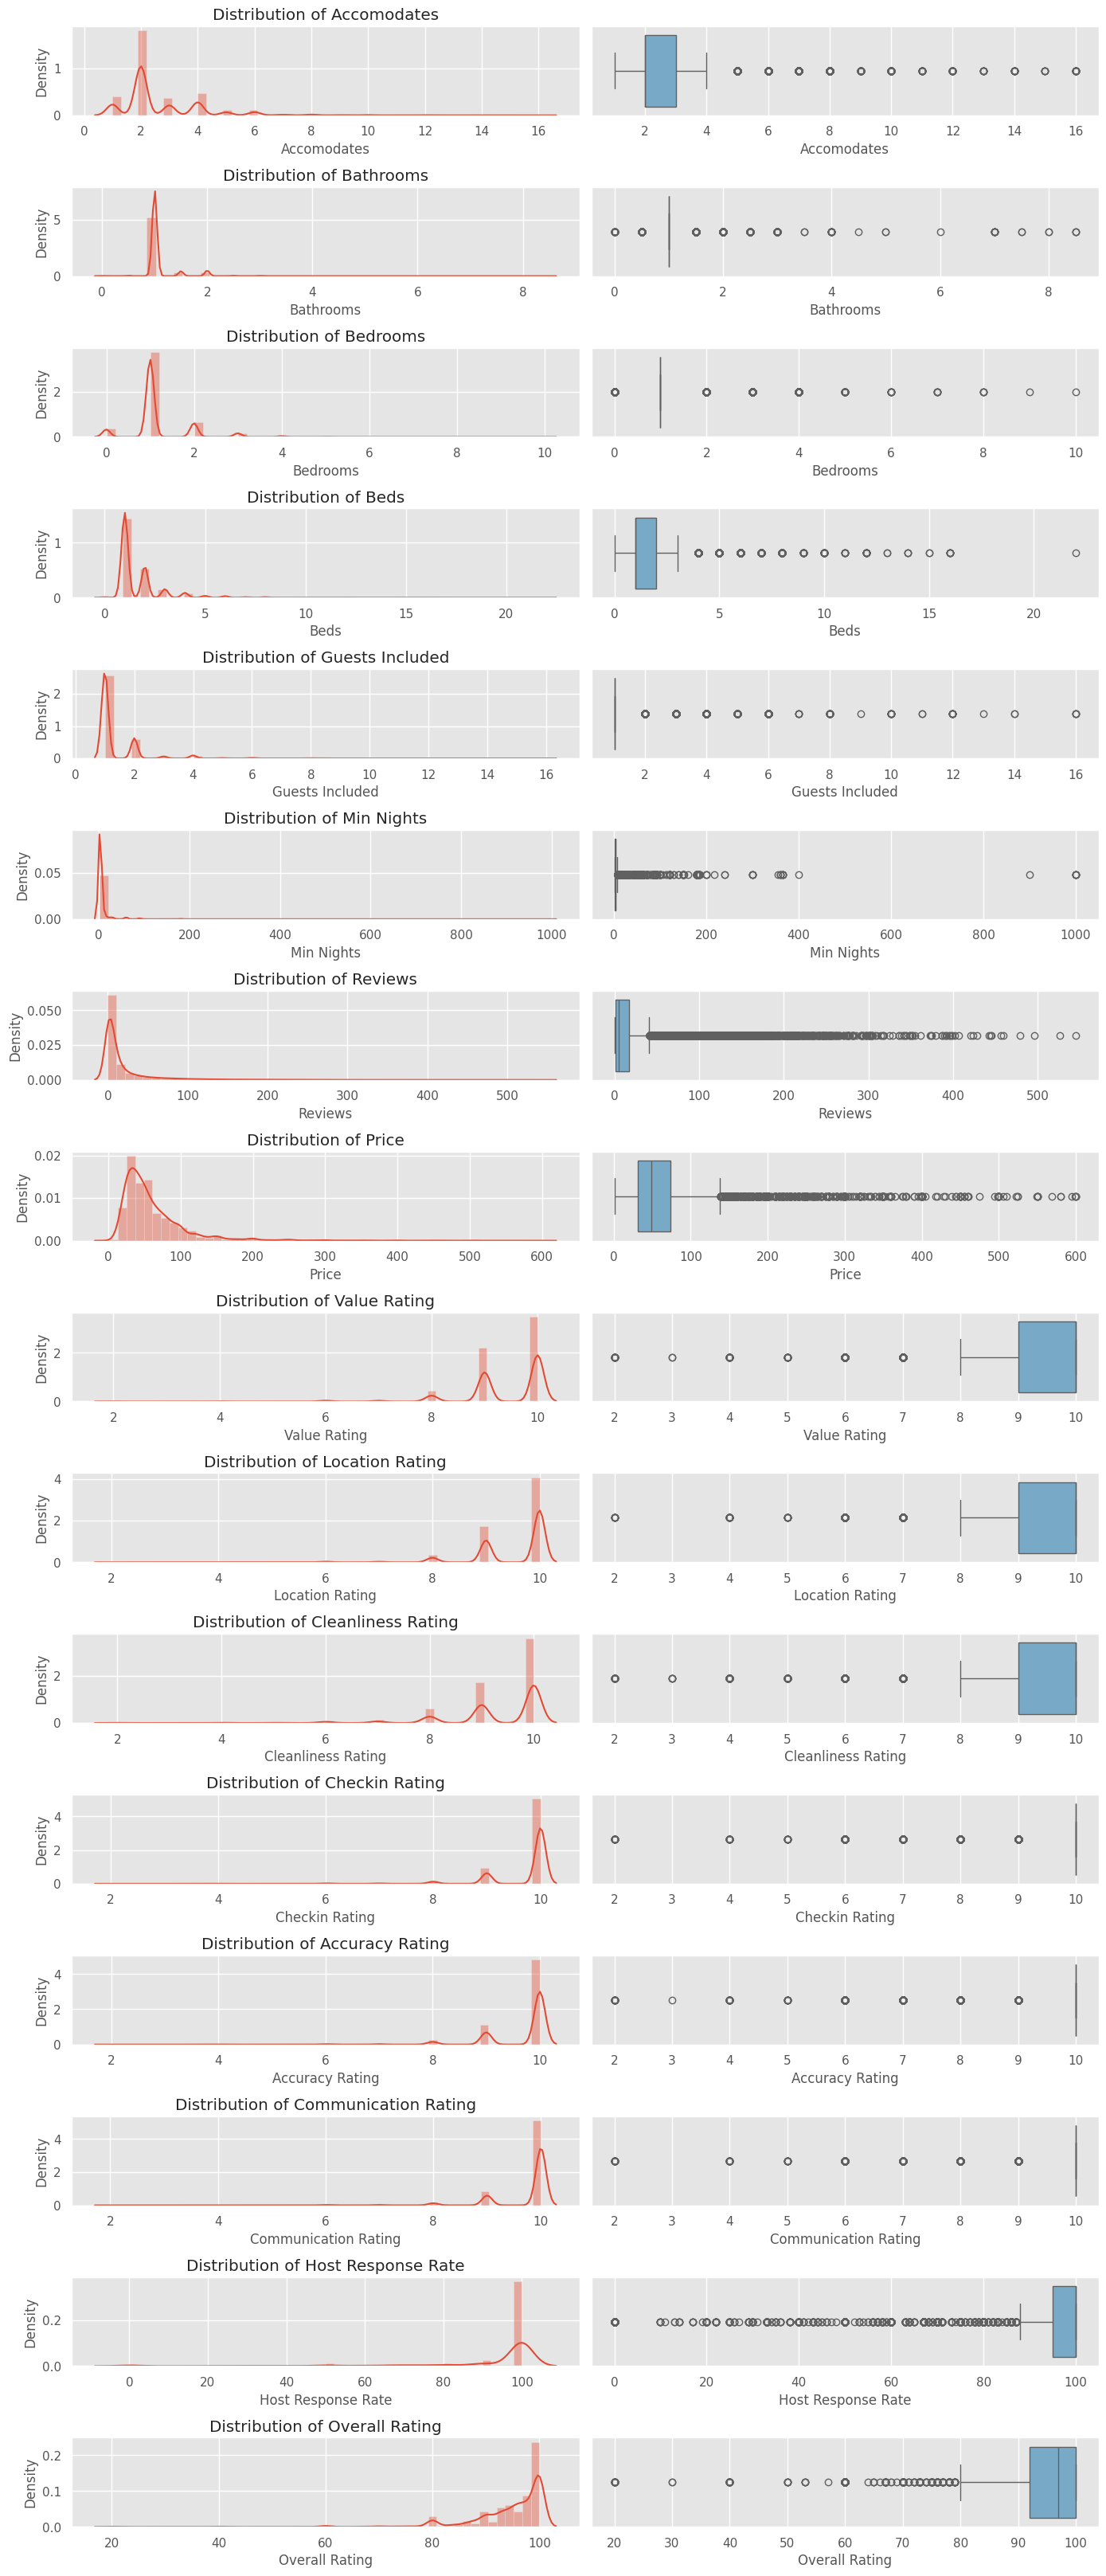

In [98]:
def outlier_boxplot(df, columns):
  plt.figure(figsize=(14, 40))
  j = 1
  for i, col in enumerate(columns, 1):
    plt.subplot(20, 2, j)
    sns.distplot(df[col].dropna())
    plt.title(f'Distribution of {col}')
    plt.subplots_adjust(hspace = 0.6)

    plt.subplot(20, 2, j + 1)
    sns.boxplot(x=df[col].dropna(), palette='Blues')
    plt.subplots_adjust(hspace = 0.6)
    j = j + 2

  plt.tight_layout()
  plt.show()

outlier_boxplot(df, numerical_columns + rating_columns)

In [99]:
# def outlier_boxplot(df, columns):
#   plt.figure(figsize=(14, 10))
#   for i, col in enumerate(columns, 1):
#   # for i, col in enumerate([c for c in numerical_columns if c not in ['Min Nights']], 1):
#     plt.subplot(5, 2, i)
#     sns.boxplot(x=df[col].dropna(), palette='Blues')
#     plt.subplots_adjust(hspace = 0.6)
#   plt.tight_layout()
#   plt.show()

# outlier_boxplot(df, numerical_columns)

The boxplots reveal potential outliers in several numerical features, particularly:

1. Price: Likely contains extreme values (high-end listings or pricing errors).
2. Reviews: Some listings have significantly higher review counts than others.
3. Bedrooms, Bathrooms, Beds, Accommodates: Some properties might have unrealistic values (e.g., too many or too few bedrooms relative to accommodations).

In [100]:
def df_describe(df, numerical_columns):
  min_vals = []
  max_vals = []
  Q1_ = []
  Q2_ = []
  Q3_ = []
  IQR_ = []
  lower_bound_ = []
  upper_bound_ = []
  for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q2 = df[column].quantile(0.50)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    min_vals.append(df[column].min())
    max_vals.append(df[column].max())
    Q1_.append(Q1)
    Q2_.append(Q2)
    Q3_.append(Q3)
    IQR_.append(IQR)
    lower_bound_.append(lower_bound)
    upper_bound_.append(upper_bound)

  # return pd.DataFrame(data = [min_vals, lower_bound_,Q1_,Q2_,Q3_ ,IQR_,upper_bound_,max_vals],
  #            columns=["min_vals", "lower_bound","Q1","Q2","Q3","IQR","upper_bound","max_vals"])
  return pd.DataFrame({
      'min': min_vals,
      'Q1(25%)': Q1_,
      'Q2(50%)': Q2_,
      'Q3(75%)': Q3_,
      'max': max_vals,
      'IQR': IQR_,
      'lower_bound': lower_bound_,
      'upper_bound': upper_bound_}, index=numerical_columns)

df_describe(df, numerical_columns + rating_columns)

,min,Q1(25%),Q2(50%),Q3(75%),max,IQR,lower_bound,upper_bound
Accomodates,1.0,2.0,2.0,3.0,16.0,1.0,0.5,4.5
Bathrooms,0.0,1.0,1.0,1.0,8.5,0.0,1.0,1.0
Bedrooms,0.0,1.0,1.0,1.0,10.0,0.0,1.0,1.0
Beds,0.0,1.0,1.0,2.0,22.0,1.0,-0.5,3.5
Guests Included,1.0,1.0,1.0,1.0,16.0,0.0,1.0,1.0
Min Nights,1.0,2.0,3.0,4.0,1000.0,2.0,-1.0,7.0
Reviews,0.0,1.0,5.0,17.0,545.0,16.0,-23.0,41.0
Price,1.0,31.0,49.0,74.0,600.0,43.0,-33.5,138.5
Value Rating,2.0,9.0,10.0,10.0,10.0,1.0,7.5,11.5
Location Rating,2.0,9.0,10.0,10.0,10.0,1.0,7.5,11.5


## Data Cleansing

In [101]:
# ## missingness correlation heatmap
# msno.heatmap(df[numerical_columns + rating_columns],figsize=(6,4))

In [102]:
con_df = df[numerical_columns].copy()

In [103]:
for col in con_df:
  print(f'{col}: {df[col].nunique()}')

Accomodates: 16
Bathrooms: 16
Bedrooms: 11
Beds: 18
Guests Included: 15
Min Nights: 97
Reviews: 332
Price: 299


In [104]:
def outliers_df(df):
    total_outliers = pd.DataFrame(columns=['Outlier count', 'Percent'])

    for col in df:  # Ensure processing numeric columns only
        temp = pd.DataFrame(df[col])
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        # Filter rows that are outliers in either direction
        temp_outliers = temp[(temp[col] > upper_limit) | (temp[col] < lower_limit)]
        num_outliers = len(temp_outliers)
        total_outliers.loc[col] = [num_outliers, num_outliers / len(df) * 100]

    return total_outliers[total_outliers['Percent'] > 0]

# Assume con_df is your DataFrame
# Call the function and sort results
outliers_df = outliers_df(con_df).sort_values('Percent', ascending=False)
outliers_df

,Outlier count,Percent
Bedrooms,5788.0,24.671782
Guests Included,5414.0,23.077579
Reviews,2980.0,12.702472
Bathrooms,2793.0,11.905371
Min Nights,2514.0,10.716113
Accomodates,2102.0,8.959932
Beds,1602.0,6.828645
Price,1381.0,5.886616


Labeling every outlier with 'Outlier'

In [105]:
def outliers(df):
    label_out_df = df.copy()
    for col in label_out_df:
        if col in outliers_df.index:
            Q1 = label_out_df[col].quantile(0.25)
            Q3 = label_out_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            label_out_df[col] = np.where(label_out_df[col] > upper_limit,'Outlier',np.where(label_out_df[col] < lower_limit,'Outlier',label_out_df[col]))
    return label_out_df
new_df_outliers = outliers(df)
new_df_outliers.head(10)

,Accomodates,Bathrooms,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Price,Value Rating,Location Rating,Cleanliness Rating,Checkin Rating,Accuracy Rating,Communication Rating,Host Response Rate,Overall Rating,Is Superhost,Is Exact Location,Instant Bookable,Room Type,Property Type Reduced,Neighborhood Group,Postal Code Reduced,Host Response Time,review_date,Host Since,Latitude,Longitude,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
0,2.0,1.0,1.0,1.0,1.0,2.0,7.0,17.0,10.0,9.0,10.0,10.0,10.0,10.0,50.0,100.0,False,True,False,Private room,Apartment,Pankow,10,within a day,07-04-18,09-16-08,52.54851,13.40455,1,0,6,0,1
1,4.0,1.0,1.0,2.0,Outlier,Outlier,Outlier,90.0,9.0,10.0,9.0,9.0,9.0,9.0,50.0,92.0,False,True,False,Entire home/apt,Apartment,Pankow,10,within a day,06-20-09,10-19-08,52.53500,13.41758,0,0,6,0,1
2,2.0,1.0,1.0,2.0,1.0,2.0,Outlier,33.0,10.0,10.0,10.0,10.0,10.0,10.0,100.0,96.0,True,True,False,Private room,Apartment,Pankow,10,within an hour,08-18-09,05-16-09,52.54316,13.41509,1,0,6,0,3
3,Outlier,Outlier,Outlier,Outlier,Outlier,6.0,6.0,Outlier,10.0,10.0,10.0,10.0,10.0,10.0,100.0,100.0,False,False,False,Entire home/apt,Apartment,Pankow,10,within a day,08-09-15,08-25-09,52.53303,13.41605,0,0,6,0,1
4,1.0,1.0,Outlier,1.0,1.0,Outlier,23.0,70.0,9.0,9.0,10.0,9.0,10.0,10.0,100.0,93.0,False,True,False,Entire home/apt,Apartment,Pankow,10,within a day,06-29-10,11-18-09,52.54785,13.40556,0,0,6,0,1
5,2.0,1.0,1.0,2.0,1.0,Outlier,0.0,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,Private room,Apartment,Friedrichshain-Kreuzberg,10,None,None,12-03-09,52.51051,13.45785,1,0,1,0,4
6,Outlier,1.0,1.0,3.0,Outlier,Outlier,Outlier,90.0,9.0,9.0,10.0,10.0,10.0,10.0,NaN,94.0,False,True,False,Entire home/apt,Apartment,Friedrichshain-Kreuzberg,10,None,06-04-10,12-20-09,52.50479,13.43510,0,0,1,0,4
7,2.0,1.0,nan,1.0,1.0,5.0,Outlier,49.0,9.0,10.0,10.0,10.0,10.0,10.0,100.0,96.0,False,False,False,Entire home/apt,Apartment,NeukÃ¶lln,12,within an hour,02-18-10,01-08-10,52.49548,13.42182,0,0,5,1,3
8,4.0,1.0,Outlier,2.0,Outlier,3.0,Outlier,129.0,9.0,10.0,9.0,9.0,9.0,9.0,100.0,88.0,False,True,False,Entire home/apt,Loft,Pankow,10,within an hour,10-03-12,01-18-10,52.53695,13.40762,0,9,6,0,3
9,4.0,1.0,1.0,2.0,Outlier,Outlier,Outlier,70.0,9.0,9.0,10.0,10.0,9.0,9.0,NaN,95.0,False,True,False,Entire home/apt,Apartment,Friedrichshain-Kreuzberg,10,None,09-23-10,12-20-09,52.50273,13.43462,0,0,1,0,4


In [106]:
# # Implementing Outlier Removal using the IQR Method
# def remove_outliers(df, column):
#     """Removes outliers based on IQR for a given column."""
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# # Applying outlier removal to selected numerical columns
# cleaned_df = df.copy()
# # for col in ["Price", "Reviews", "Bedrooms", "Bathrooms", "Beds", "Accomodates"]:
# #     cleaned_df = remove_outliers(cleaned_df, col)

# # Displaying summary after outlier removal
# cleaned_df.head(5)

# to_pickle

In [107]:
df.to_pickle("/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl")

In [108]:
# df_Feature_Engineering = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl')
# df_Feature_Engineering.info()